<a href="https://colab.research.google.com/github/BrunuCosta/students_GPA_regression/blob/main/students_burnout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Burnout em Estudantes Usando Machine Learning

## Problema e relevância
Este trabalho tem como objetivo desenvolver um modelo de classificação para prever a ocorrência de burnout em estudantes, com base em dados comportamentais e acadêmicos. A escolha desse problema se justifica pela crescente relevância da saúde mental no ambiente educacional. Um modelo capaz de identificar padrões associados ao burnout poderia auxiliar instituições na adoção de medidas preventivas, desde que aplicado a dados reais.

Para este estudo, utilizamos uma base de dados sintética disponível no Kaggle, que simula relações entre variáveis como horas de sono, tempo de tela, nível de ansiedade e desempenho acadêmico. Embora os dados não sejam reais, eles permitem explorar todo o fluxo de um projeto de Machine Learning sem as limitações éticas e práticas de dados sensíveis.

## Por que usar um sistema inteligente?
A escolha por modelos supervisionados de classificação, em detrimento de abordagens puramente estatísticas ou baseadas em regras, é motivada por dois fatores principais. Primeiro, modelos como LDA e Árvore de Decisão oferecem uma alta interpretabilidade,  permitindo identificar quais variáveis mais influenciam a classificação de um estudante como em risco de burnout, o que agrega valor prático à análise e orienta intervenções individuais/personalizadas. Segundo, diferentemente de análises univariadas ou limiares fixos, os modelos de Machine Learning são capazes de capturar interações não-lineares e padrões complexos entre múltiplas variáveis simultaneamente, resultando em previsões mais precisas e robustas.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, confusion_matrix
from sklearn.decomposition import PCA

from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Importação e explicação da base de dados

In [2]:
dataset = pd.read_csv('student_sleep_mental_health_2026.csv')

# Removendo coluna de indice
dataset.drop(columns=['student_id'], inplace=True)

# Formatação da coluna para evitar erros por de espaço
dataset['education_level'] = dataset['education_level'].str.replace(' ', '').str.lower()

print(f'Dimensões: {dataset.shape[0]} linhas × {dataset.shape[1]} colunas')

# Verificação de dados nulos ou duplicados
print(f'Valores ausentes: {dataset.isna().sum().sum()}')
print(f'Duplicatas: {dataset.duplicated().sum()}')
dataset.head()

Dimensões: 3000 linhas × 14 colunas
Valores ausentes: 0
Duplicatas: 0


,age,gender,education_level,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa,uses_sleep_app,feels_burned_out
0,21,Non-binary,highschool,8.0,4.9,3.7,5.0,4.8,1,7,7,3.35,False,True
1,19,Female,undergraduate,7.3,7.7,5.3,2.8,4.2,1,8,8,2.81,True,True
2,19,Male,undergraduate,6.1,7.3,3.6,3.6,5.8,1,8,10,3.01,True,True
3,16,Male,highschool,6.2,7.4,4.0,0.4,2.0,4,9,10,2.76,False,True
4,20,Male,graduate,5.6,12.5,8.3,2.6,6.2,3,10,10,2.67,False,True


#### 2.1 Explicação das colunas da base de dados
**education_level**: Se está no ensino médio, graduação, ou pós-graduação.

**avg_sleep_hours**, **screen_time_hours**, **social_media_hours**: Horas de sono, de tela e gasto em redes sociais por dia.

**study_hours_per_day**: Horas de estudo por dia.

**exercise_hours_per_week**: Horas gastas com exercicios físicos na semana.

**caffeine_drinks_per_day**: Quantidade de cafés tomados por dia.

**stress_level**,	**anxiety_score**: Autoavaliação de 1 a 10 no nível de stress e ansiedade.

**gpa**: Média das notas acadêmicas, indo de 0 a 4, como se fosse o CR.

**uses_sleep_app**: Se usa algum aplicativo que ajuda no sono.

**feels_burned_out (target)**: Se a pessoa apresenta burnout.

### 2.2 Análise exploratória

#### 2.2.1 Avaliando distribuição da variável alvo

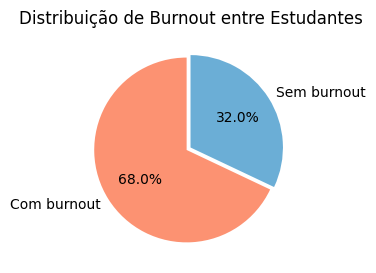

In [3]:
target = 'feels_burned_out'
# Configurar o estilo visual do Seaborn

contagem = dataset[target].value_counts()

# Configuração do gráfico de pizza
plt.figure(figsize=(3, 3))
plt.pie(contagem,
        labels=['Com burnout', 'Sem burnout'],
        colors=['#FC9272', '#6BAED6'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0))
plt.title('Distribuição de Burnout entre Estudantes')
plt.show()


*A base possui dados com a variável target desbalanceada, fazendo então necessário utilizar de uma amostra de dados estratificada posteriormente, para manter a proporção das classes.*

#### 2.2.2 Análise de correlação e vazamento de informação

Correlações com o Burn out:
feels_burned_out           1.000000
stress_level               0.794829
anxiety_score              0.608192
screen_time_hours          0.408392
social_media_hours         0.307210
uses_sleep_app             0.007982
age                        0.007975
study_hours_per_day       -0.017321
caffeine_drinks_per_day   -0.020613
exercise_hours_per_week   -0.242224
avg_sleep_hours           -0.386412
gpa                       -0.443721
Name: feels_burned_out, dtype: float64


<Axes: >

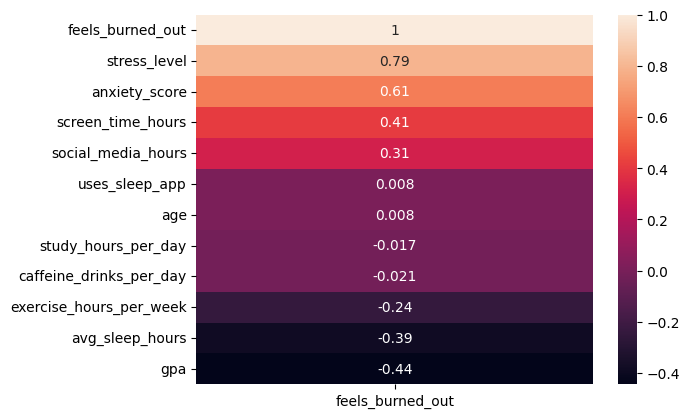

In [4]:
# Calcula a correlação de Pearson de todas as colunas numéricas com o GPA
correlacoes = dataset.corr(numeric_only=True, method='pearson')[target].sort_values(ascending=False)

print("Correlações com o Burn out:")
print(correlacoes)
sns.heatmap(correlacoes.to_frame(), annot=True)

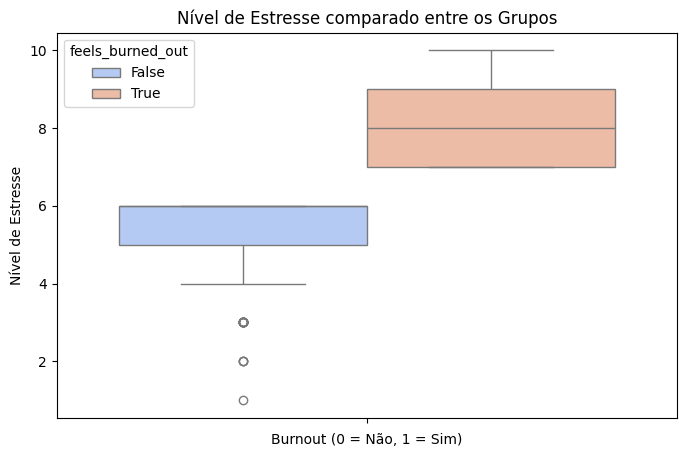

In [5]:
plt.figure(figsize=(8, 5))
# Colocamos o Burnout no X e a variável que queremos investigar no Y
sns.boxplot(data=dataset, hue='feels_burned_out', y='stress_level', palette='coolwarm')

plt.title("Nível de Estresse comparado entre os Grupos")
plt.xlabel("Burnout (0 = Não, 1 = Sim)")
plt.ylabel("Nível de Estresse")
plt.show()

In [6]:
# @title
# AVALIAR SE MANTÉM ESSA PARTE DO CÓDIGO

def verif_desvio_padrao(variavel_investigada, dataset):
    dataset['faixas_investigadas'] = pd.qcut(dataset[variavel_investigada], q=5, duplicates='drop')

    analise_vazamento = dataset.groupby('faixas_investigadas', observed=False)['feels_burned_out'].agg(
        Desvio_Padrao='std',
        Media='mean',
        Qtd_Alunos='count'
    )

    print(f"--- Análise de Vazamento para a variável: '{variavel_investigada}' ---")
    print(analise_vazamento)

    vazamento = analise_vazamento[(analise_vazamento['Desvio_Padrao'] == 0) &
                                (analise_vazamento['Qtd_Alunos'] > 1)]

    if not vazamento.empty:
        print("\nPossível vazamento detectado (Relação Determinística)!")
        print("Os grupos possuem Desvio Padrão ZERO, ou seja, todos os alunos têm exatamente o mesmo índice de burnout.")
    else:
        print("\nNão há vazamento de informações. Há variação (desvio padrão > 0) no índice de burnout dentro de todos os grupos.\n")

    # Opcional: remover a coluna de faixas criada para não sujar o dataset
    dataset = dataset.drop(columns=['faixas_investigadas'])

verif_desvio_padrao('stress_level', dataset)
dataset.drop(['faixas_investigadas'], axis=1, inplace=True)

--- Análise de Vazamento para a variável: 'stress_level' ---
                     Desvio_Padrao  Media  Qtd_Alunos
faixas_investigadas                                  
(0.999, 6.0]                   0.0    0.0         961
(6.0, 7.0]                     0.0    1.0         740
(7.0, 8.0]                     0.0    1.0         646
(8.0, 9.0]                     0.0    1.0         414
(9.0, 10.0]                    0.0    1.0         239

Possível vazamento detectado (Relação Determinística)!
Os grupos possuem Desvio Padrão ZERO, ou seja, todos os alunos têm exatamente o mesmo índice de burnout.


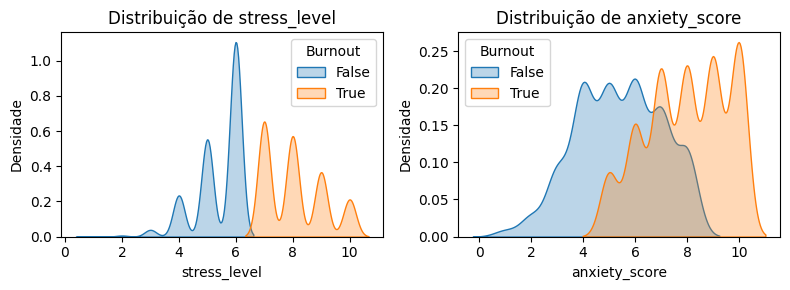

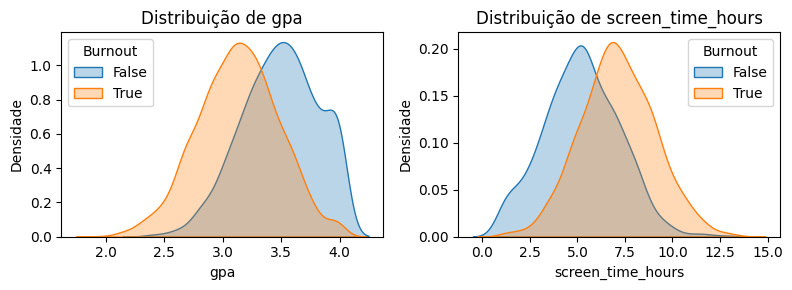

In [7]:
# Plotando um grafico para as variáveis mais correlacionadas com o problema
variaveis = ['stress_level', 'anxiety_score', 'gpa', 'screen_time_hours']
pares = [(variaveis[0], variaveis[1]), (variaveis[2], variaveis[3])]

for par in pares:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    for i, var in enumerate(par):
        for valor in [0, 1]:
            subset = dataset[dataset['feels_burned_out'] == valor]
            sns.kdeplot(data=subset, x=var, ax=axes[i],
                        label=f'{bool(valor)}',
                        fill=True, alpha=0.3, common_norm=False)

        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Densidade')
        axes[i].set_title(f'Distribuição de {var}')
        axes[i].legend(title='Burnout')

    plt.tight_layout()
    plt.show()

Conclusões: Por causa da correlação muito alta **(0.79)** entre a variável **stress_level** e **feels_burned_out**, e da nítida divisão dos dados que pode ser vista no gráfico. Acredita-se que, por ser uma base sintética, a coluna 'feels_burned_out' foi criada usando a stress_level de base. O que para nosso algorítmo, seria um **vazamento de informação**, por isso **essa coluna será removida**.

Fora isso, as outras colunas se mostram com uma diferença relevantes entre as classes. Não o suficiente para se traçar um limiar apenas e chegar num resultado satisfatório. Porém, é o tipo de diferença em que os modelos podem se destacar em conseguir classificar melhor.



### 2.3 Pré-processamento e divisão dos dados de Treino e Teste

In [8]:
# Remoção das colunas que serão desconsideradas
# Por questões de boas práticas, para evitar viés do modelo, a coluna de genero também vai ser desconsiderada
dataset.drop(columns=['gender', 'stress_level'], inplace=True)

# Transformar colunas binarias
colunas_binarias = ['uses_sleep_app',
                    'feels_burned_out']
for col in colunas_binarias:
    dataset[col] = dataset[col].astype(int)

# Divisão dos dados em Treino e Teste, utilizando amostra estratificada
y = dataset[target]
X = dataset.drop(columns=[target])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normaliza os dados numericos
colunas_numericas = ['avg_sleep_hours',
                     'screen_time_hours',
                     'social_media_hours',
                     'study_hours_per_day',
                     'exercise_hours_per_week',
                     'anxiety_score',
                     'gpa',
                     'age']

# Deve ser feito após a divisão dos dados, para os parametros de normalização não virem com vazamento de informação do conjunto de teste
scaler = StandardScaler()
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

# Transformação de variáveis categóricas em variáveis numéricas, mantendo a ordem natural das categorias
ordem_educacao = [['highschool', 'undergraduate', 'graduate']]
encoder = OrdinalEncoder(categories=ordem_educacao, handle_unknown='use_encoded_value', unknown_value=-1)
X_train['education_level'] = encoder.fit_transform(X_train[['education_level']])
X_test['education_level'] = encoder.transform(X_test[['education_level']])


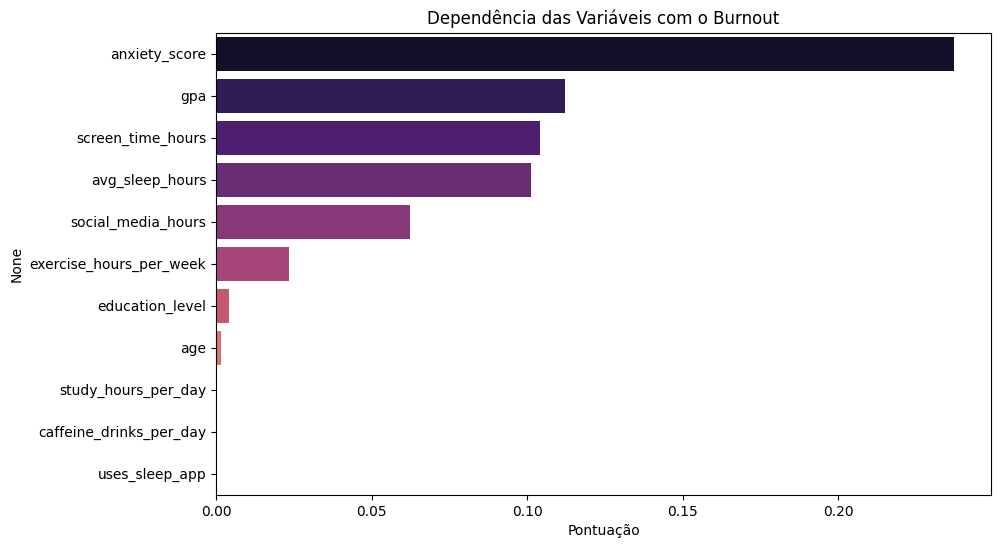

In [9]:
from sklearn.feature_selection import mutual_info_classif
mi_scores_classif = mutual_info_classif(X_train, y_train, random_state=42)

# 3. Organizar e plotar
mi_series_classif = pd.Series(mi_scores_classif, index=X_train.columns, name="Info Mútua (Classificação)")
mi_series_classif = mi_series_classif.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series_classif.values, y=mi_series_classif.index, hue=mi_series_classif.index, palette="magma", legend=False)
plt.title("Dependência das Variáveis com o Burnout")
plt.xlabel("Pontuação")
plt.show()

## 3. Aplicação dos modelos de predição

In [10]:
def avaliar_modelos(modelos_dict, X_test, y_test):
    num_modelos = len(modelos_dict)

    # CURVA ROC COMPARATIVA
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Aleatório (AUC = 0.50)')
    
    for nome, modelo in modelos_dict.items():
        # Identificação das probabilidades individuais para cada modelo
        if hasattr(modelo, "predict_proba"):
            y_prob = modelo.predict_proba(X_test)[:, 1] # Probabilidade da classe 1 (Burnout)
        elif hasattr(modelo, "decision_function"):
            y_prob = modelo.decision_function(X_test)
        else:
            y_prob = modelo.predict(X_test)
            
        # Cálculo da Taxa de Falso Positivo (fpr) e Taxa de Verdadeiro Positivo (tpr)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        if(roc_auc > 0.89):
            plt.plot(fpr, tpr, lw=2, label=f'{nome} (AUC = {roc_auc:.3f})')
        
    plt.title('Curva ROC - Comparação dos Modelos (Burnout)', fontsize=14, pad=15)
    plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()

    # MATRIZ DE CONFUSÃO
    cols = 3
    rows = (num_modelos + cols - 1) // cols 
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4.5 * rows))
    axes = axes.flatten() # Achatar o array de eixos para iterar facilmente
    
    for i, (nome, modelo) in enumerate(modelos_dict.items()):
        # Para a Matriz de Confusão, usamos a previsão final (0 ou 1)
        y_pred = modelo.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        # Criar o mapa de calor (heatmap)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False, annot_kws={"size": 14})
        axes[i].set_title(f'{nome}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Previsto pelo Modelo', fontsize=11)
        axes[i].set_ylabel('Realidade', fontsize=11)
        
        axes[i].set_xticklabels(['Sem Burnout (0)', 'Com Burnout (1)'])
        axes[i].set_yticklabels(['Sem Burnout (0)', 'Com Burnout (1)'])
        
    # Esconder os subplots extras que ficarem vazios no grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

In [11]:
# Dicionário com os classificadores
classifiers = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LDA': LinearDiscriminantAnalysis(),
    'SVC': SVC(kernel='rbf', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42)
}

# Lista para armazenar os resultados
resultados = []

# Testar cada classificador
for nome, modelo in classifiers.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)

    resultados.append({
        'Classificador': nome,
        'Acurácia': f'{acuracia:.4f}'
    })

    print(f'--- {nome} ---')
    print(f'Acurácia: {acuracia:.4f}')
    print('Relatório de Classificação:')
    print(classification_report(y_test, y_pred))
    print('Matriz de Confusão:')
    print(confusion_matrix(y_test, y_pred))
    print('='*50)
    print()

# DataFrame com os resultados comparativos
df_resultados = pd.DataFrame(resultados)
print('--- RESUMO COMPARATIVO ---')
print(df_resultados.to_string(index=False))

--- KNN ---
Acurácia: 0.8067
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.74      0.61      0.67       192
           1       0.83      0.90      0.86       408

    accuracy                           0.81       600
   macro avg       0.79      0.75      0.77       600
weighted avg       0.80      0.81      0.80       600

Matriz de Confusão:
[[117  75]
 [ 41 367]]

--- LDA ---
Acurácia: 0.8383
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73       192
           1       0.86      0.90      0.88       408

    accuracy                           0.84       600
   macro avg       0.82      0.80      0.81       600
weighted avg       0.84      0.84      0.84       600

Matriz de Confusão:
[[134  58]
 [ 39 369]]

--- SVC ---
Acurácia: 0.8183
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.6

c:\Users\maria\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


--- MLP ---
Acurácia: 0.8300
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       192
           1       0.87      0.88      0.88       408

    accuracy                           0.83       600
   macro avg       0.81      0.80      0.80       600
weighted avg       0.83      0.83      0.83       600

Matriz de Confusão:
[[139  53]
 [ 49 359]]

--- DecisionTree ---
Acurácia: 0.8200
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.65      0.70       192
           1       0.85      0.90      0.87       408

    accuracy                           0.82       600
   macro avg       0.80      0.78      0.79       600
weighted avg       0.82      0.82      0.82       600

Matriz de Confusão:
[[125  67]
 [ 41 367]]

--- Regressão Logística ---
Acurácia: 0.8383
Relatório de Classificação:
              precision    recall  f1-score   support

       

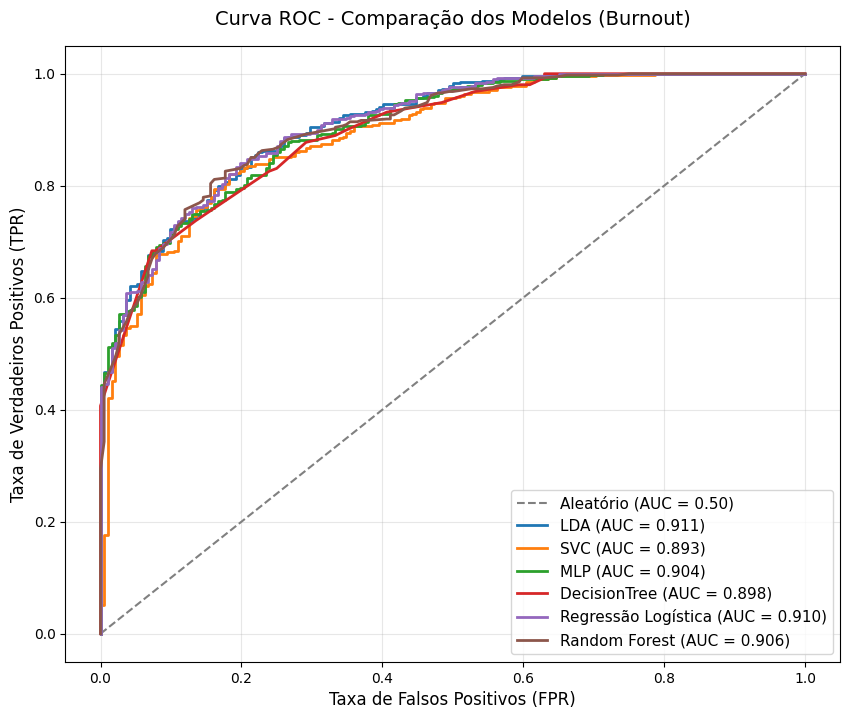

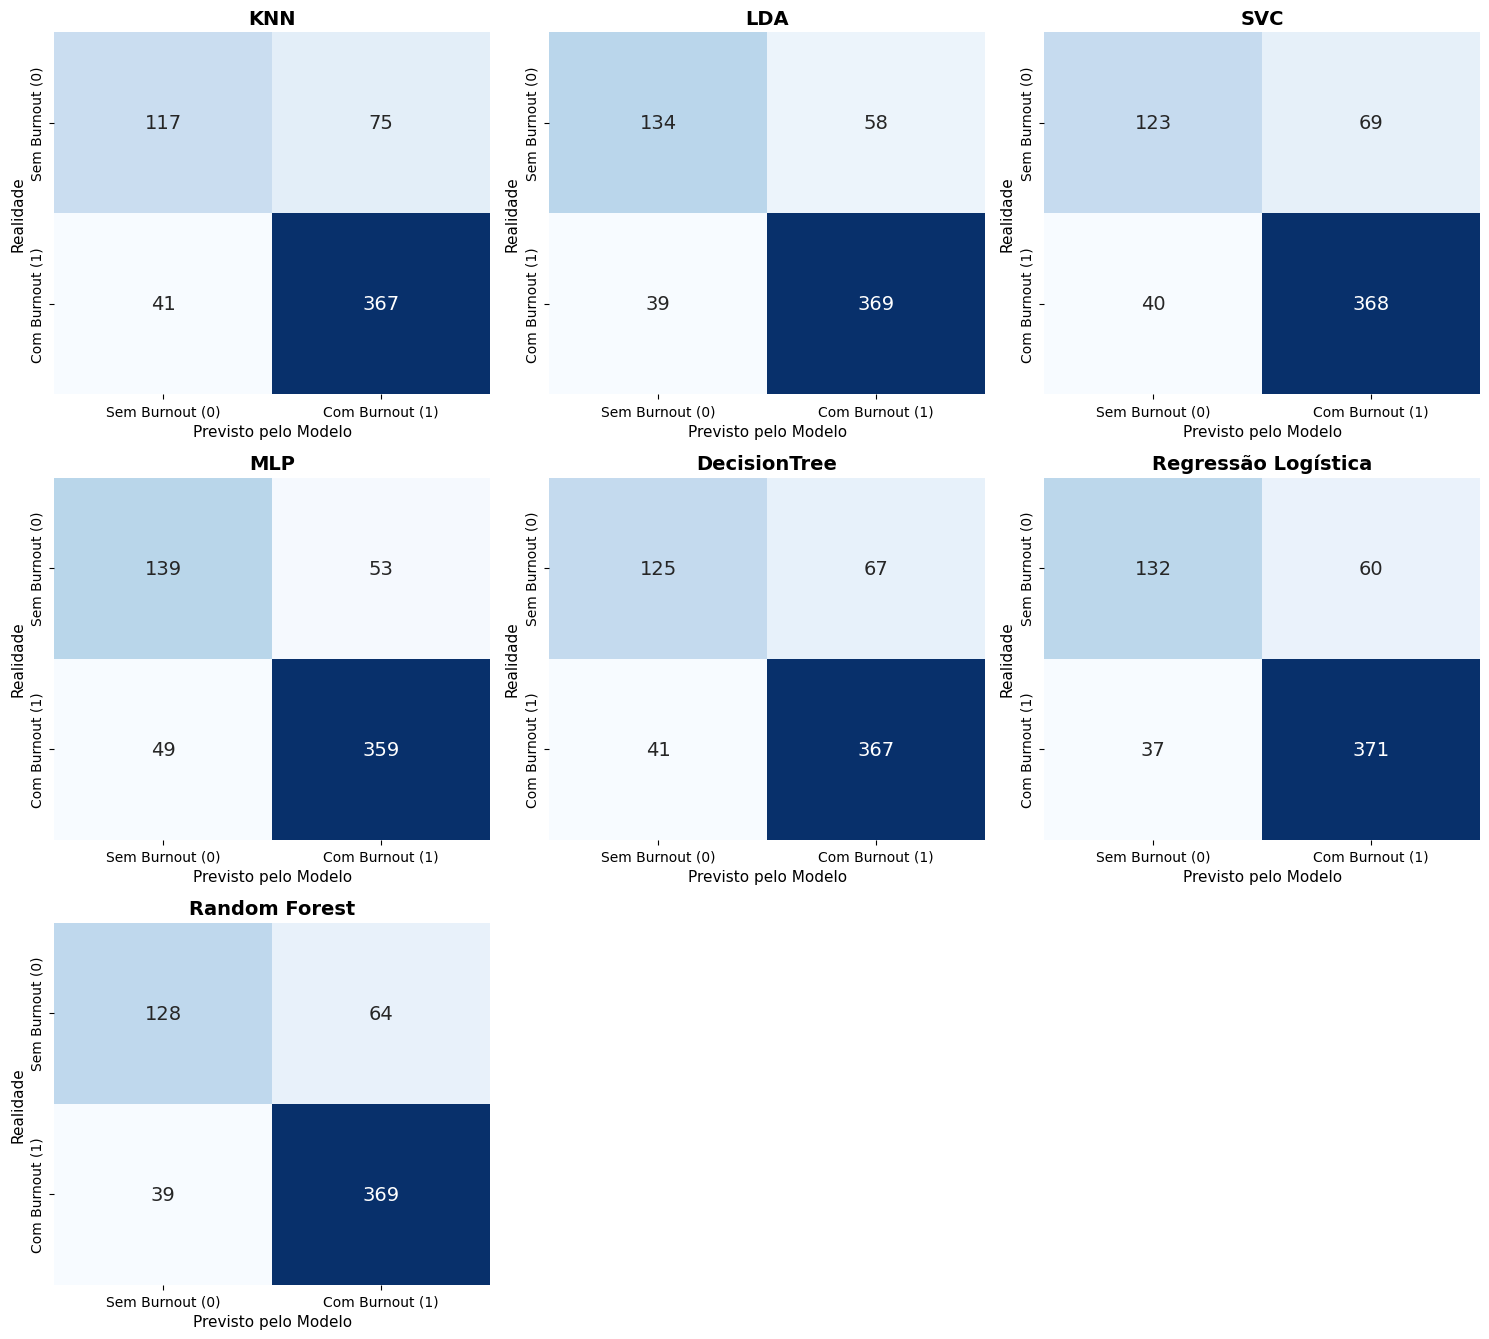

In [12]:
avaliar_modelos(classifiers, X_test, y_test)

In [13]:
# Avaliar os resultados da melhor acurácia ( LDA ) e explicar as variáveis mais relevantes

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

coeficientes = lda.coef_[0]

# Criar DataFrame com os nomes das variáveis e seus coeficientes
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': coeficientes,
    'Importância_Absoluta': np.abs(coeficientes)
})

# Ordenar por importância (do maior para o menor)
importancias = importancias.sort_values('Importância_Absoluta', ascending=False)

print('--- Importância das Variáveis no LDA ---')
print(importancias)

--- Importância das Variáveis no LDA ---
                   Variável  Coeficiente  Importância_Absoluta
8             anxiety_score     1.726638              1.726638
9                       gpa    -0.648687              0.648687
3         screen_time_hours     0.594038              0.594038
6   exercise_hours_per_week    -0.476462              0.476462
2           avg_sleep_hours    -0.263323              0.263323
10           uses_sleep_app     0.140260              0.140260
4        social_media_hours    -0.126114              0.126114
0                       age     0.093516              0.093516
5       study_hours_per_day    -0.052171              0.052171
7   caffeine_drinks_per_day    -0.006630              0.006630
1           education_level    -0.001911              0.001911


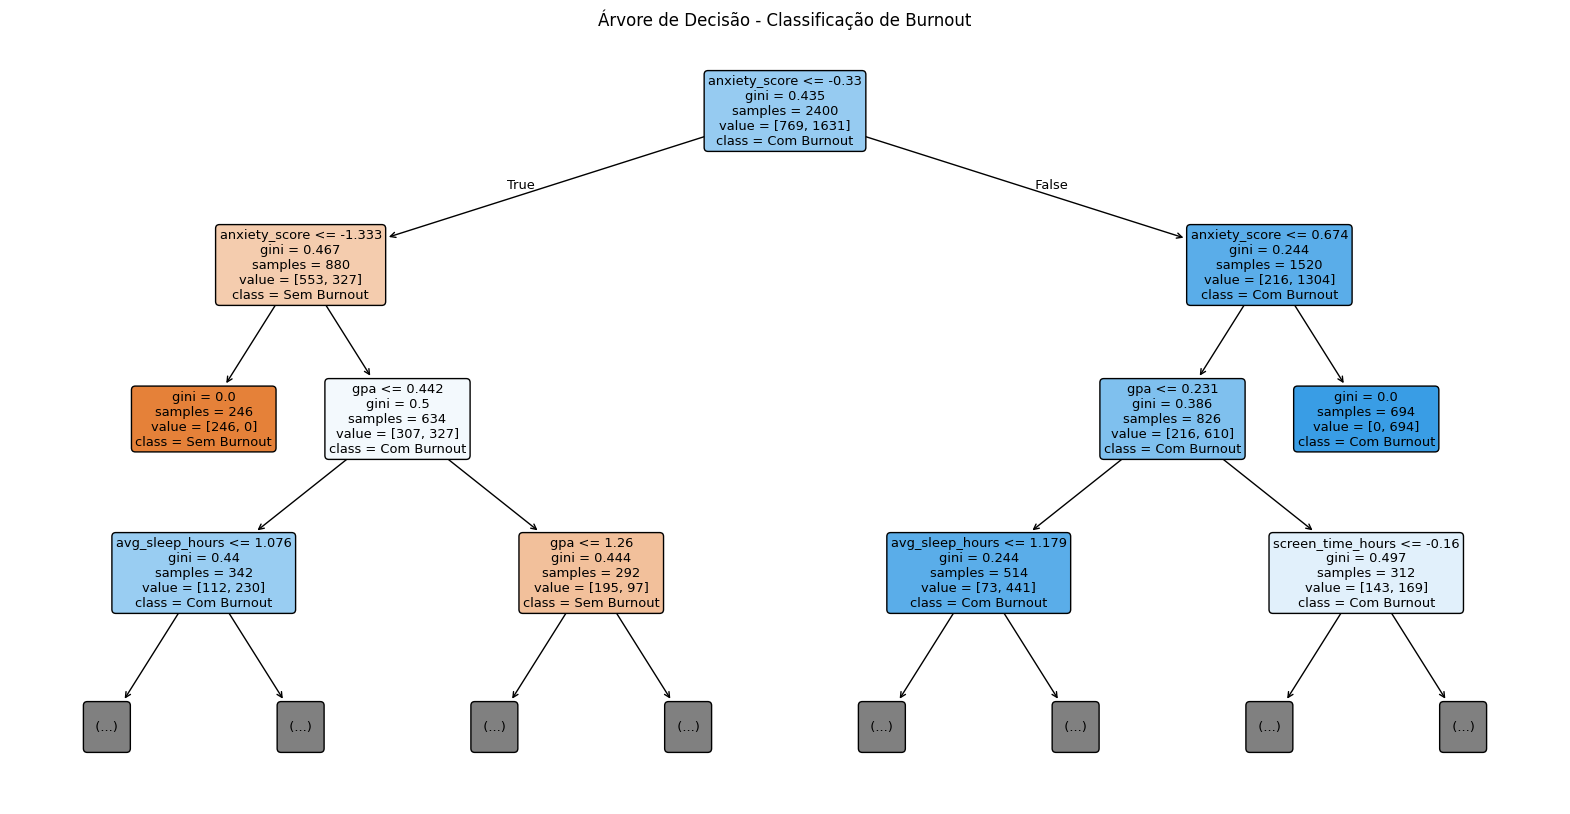

In [14]:
# Visualizar com o modelo de árvore faz a decisão de classificação
# Útil para entender de forma individual quais fatores levaram o modelo a classificar alguém com burnout ou não

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['Sem Burnout', 'Com Burnout'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title('Árvore de Decisão - Classificação de Burnout')
plt.show()


In [15]:
# Se avaliarmos apenas o anxiety_score, e fizermos uma heurística simples?
# Se o score for menor que -0,33 (Limiar onde tem mais pessoas sem burnout) classificamos como 'sem burnout', caso contrário, marca 'com burnout'
# É uma boa maneira de avaliar se nosso modelo performa melhor que uma análise de dados simples
y_pred_heuristica = np.where(X_test['anxiety_score'] >= -0.33, 1, 0)
# Calcular as métricas
acuracia = accuracy_score(y_test, y_pred_heuristica)
precisao = precision_score(y_test, y_pred_heuristica)
recall = recall_score(y_test, y_pred_heuristica)
f1 = f1_score(y_test, y_pred_heuristica)
matriz_confusao = confusion_matrix(y_test, y_pred_heuristica)

# Exibir os resultados
print('--- HEURÍSTICA: anxiety_score <= -0.33 -> Classe 1 (Burnout) ---')
print(f'Acurácia: {acuracia:.4f}')
print(f'Precisão: {precisao:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print('\nMatriz de Confusão:')
print(matriz_confusao)
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_heuristica, target_names=['Sem Burnout', 'Com Burnout']))

--- HEURÍSTICA: anxiety_score <= -0.33 -> Classe 1 (Burnout) ---
Acurácia: 0.7833
Precisão: 0.8620
Recall: 0.8113
F1-Score: 0.8359

Matriz de Confusão:
[[139  53]
 [ 77 331]]

Relatório de Classificação:
              precision    recall  f1-score   support

 Sem Burnout       0.64      0.72      0.68       192
 Com Burnout       0.86      0.81      0.84       408

    accuracy                           0.78       600
   macro avg       0.75      0.77      0.76       600
weighted avg       0.79      0.78      0.79       600

